In [1]:
import nfl_data_py as nfl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All good Josh - ready!")

All good Josh - ready!


In [2]:
pbp = nfl.import_pbp_data([2022, 2023, 2024])

print(pbp.shape)

2022 done.
2023 done.
2024 done.
Downcasting floats.
(148591, 397)


In [3]:
plays = pbp[
    (pbp['play_type'].isin(['run', 'pass']))
    & (pbp['epa'].notna())
    & (pbp['down'].isin([1, 2, 3]))
    & (pbp['ydstogo'] > 0)
    & (pbp['qb_kneel'] != 1)
    & (pbp['qb_spike'] != 1)
].copy()

print(f"plays remaining: {len(plays)}")

plays remaining: 103262


In [4]:
def distance_bucket(ydstogo):
    if ydstogo <= 3:
        return 'Short (1-3)'
    elif ydstogo <= 7:
        return 'Medium (4-7)'
    else:
        return 'Long (8+)'
        
plays['distance_bucket'] = plays['ydstogo'].apply(distance_bucket)

print(plays['distance_bucket'].value_counts())

distance_bucket
Long (8+)       70411
Medium (4-7)    19864
Short (1-3)     12987
Name: count, dtype: int64


In [5]:
summary = (
    plays
    .groupby(['down', 'distance_bucket', 'play_type'])
    .agg(
        avg_epa = ('epa', 'mean'),
        success_rate = ('success', 'mean'),
        play_count = ('epa', 'count')
    )
    .reset_index()
)

summary = summary[summary['play_count'] >= 50]

summary['avg_epa'] = summary['avg_epa'].round(3)
summary['success_rate'] = summary['success_rate'].round(3)

print(summary)
    

    down distance_bucket play_type  avg_epa  success_rate  play_count
0    1.0       Long (8+)      pass    0.057         0.475       21457
1    1.0       Long (8+)       run   -0.082         0.364       22487
2    1.0    Medium (4-7)      pass   -0.039         0.442         455
3    1.0    Medium (4-7)       run    0.042         0.482         888
4    1.0     Short (1-3)      pass   -0.142         0.417         264
5    1.0     Short (1-3)       run    0.049         0.520         685
6    2.0       Long (8+)      pass    0.018         0.427       12487
7    2.0       Long (8+)       run   -0.092         0.338        5442
8    2.0    Medium (4-7)      pass    0.110         0.504        6130
9    2.0    Medium (4-7)       run    0.030         0.455        5383
10   2.0     Short (1-3)      pass    0.039         0.537        2103
11   2.0     Short (1-3)       run    0.037         0.557        3611
12   3.0       Long (8+)      pass   -0.176         0.290        7419
13   3.0       Long 

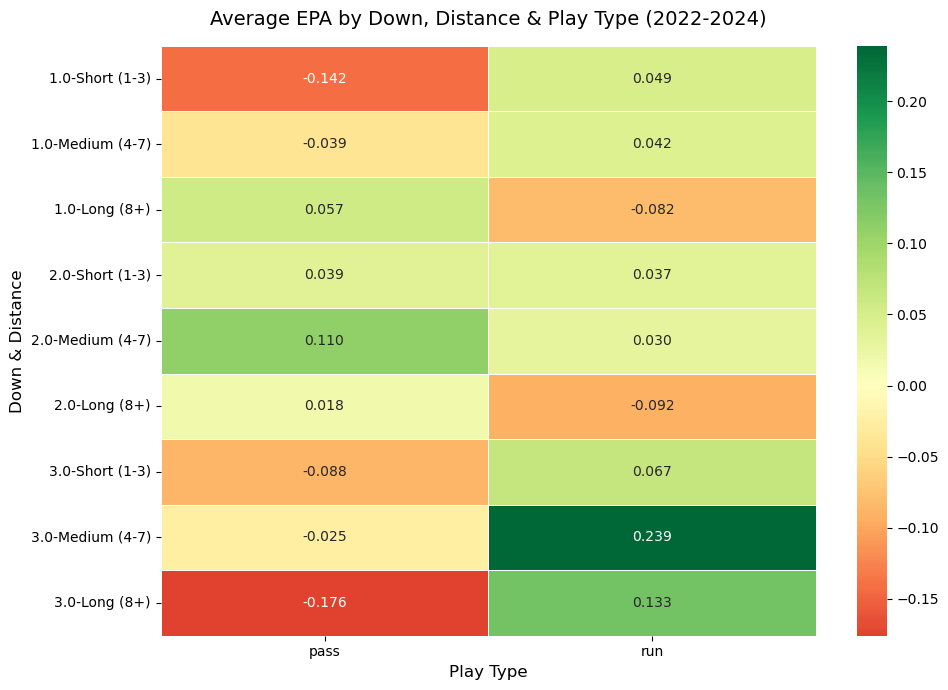

In [6]:
heatmap_data = summary.pivot_table(
    index=['down', 'distance_bucket'],
    columns='play_type',
    values='avg_epa',
)

row_order = [
    (1, 'Short (1-3)'), (1, 'Medium (4-7)'), (1, 'Long (8+)'),
    (2, 'Short (1-3)'), (2, 'Medium (4-7)'), (2, 'Long (8+)'),
    (3, 'Short (1-3)'), (3, 'Medium (4-7)'), (3, 'Long (8+)'),
]
heatmap_data = heatmap_data.reindex(row_order)
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidth=0.5,
    ax=ax
)

ax.set_title('Average EPA by Down, Distance & Play Type (2022-2024)',
             fontsize=14, pad=15)
ax.set_xlabel('Play Type', fontsize=12)
ax.set_ylabel('Down & Distance', fontsize=12)

plt.tight_layout()
plt.savefig('epa_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()         

In [7]:
summary_wide = summary.pivot_table(
    index=['down', 'distance_bucket'],
    columns='play_type',
    values='avg_epa'
).reset_index()

summary_wide['epa_gap'] = (summary_wide['pass'] - summary_wide['run']).round(3)
summary_wide['better_call'] = summary_wide['epa_gap'].apply(
    lambda x: 'Pass' if x > 0 else 'Run'
)

print(summary_wide[['down', 'distance_bucket', 'pass', 'run', 'epa_gap', 'better_call']]
      .sort_values('epa_gap', key=abs, ascending=False))

play_type  down distance_bucket   pass    run  epa_gap better_call
6           3.0       Long (8+) -0.176  0.133   -0.309         Run
7           3.0    Medium (4-7) -0.025  0.239   -0.264         Run
2           1.0     Short (1-3) -0.142  0.049   -0.191         Run
8           3.0     Short (1-3) -0.088  0.067   -0.155         Run
0           1.0       Long (8+)  0.057 -0.082    0.139        Pass
3           2.0       Long (8+)  0.018 -0.092    0.110        Pass
1           1.0    Medium (4-7) -0.039  0.042   -0.081         Run
4           2.0    Medium (4-7)  0.110  0.030    0.080        Pass
5           2.0     Short (1-3)  0.039  0.037    0.002        Pass


In [8]:
# Save file
summary_wide.to_csv('nfl_playcalling_findings.csv', index=False)

print("Saved future Analyst!")

Saved future Analyst!
